# Regresión Logística
`jhoyos`



# Introducción

La regresión logística es uno de los algoritmos fundamentales del aprendizaje supervisado para problemas de clasificación. A diferencia de la regresión lineal, que predice valores continuos, la regresión logística estima la probabilidad de que una observación pertenezca a una clase determinada, transformando una combinación lineal de las variables de entrada mediante la función sigmoide (Lee, 2019).

- **Fundamentos:** derivación de la función sigmoide, función de costo (log-loss) y gradiente descendente.
- **Regularización L1 (Lasso) y L2 (Ridge):** control del sobreajuste y selección de características.
- **Validación cruzada estratificada:** estimación robusta del rendimiento del modelo.
- **Curvas ROC y Precision-Recall:** evaluación detallada de la capacidad discriminativa.
- **Análisis de umbral de decisión:** impacto del punto de corte en las métricas.
- **Frontera de decisión:** visualización del límite entre clases en un espacio 2D.

Se utiliza el dataset **Wisconsin Breast Cancer** (569 muestras, 30 características), un referente en clasificación binaria, para ilustrar cómo la regresión logística puede aplicarse al diagnóstico médico (Theodoridis, 2015).



### ¿Identifican los conjuntos de datos a los cuales se puede aplicar la regresión logística?

La regresión logística es aplicable a conjuntos de datos con las siguientes características:

- **Variable dependiente categórica:** binaria (sí/no, maligno/benigno, spam/no spam) o multiclase (mediante extensiones como softmax).
- **Variables independientes numéricas o codificadas:** las variables predictoras pueden ser continuas o categóricas codificadas numéricamente.
- **Relación lineal entre predictores y log-odds:** la regresión logística asume que el logaritmo de las probabilidades (logit) es una función lineal de las variables de entrada.
- **Observaciones independientes:** cada observación debe ser independiente de las demás.

**Ejemplos de datasets aplicables:**
- Diagnóstico médico: cáncer benigno vs. maligno (Wisconsin Breast Cancer).
- Detección de fraude: transacción legítima vs. fraudulenta.
- Análisis de crédito: cliente solvente vs. en riesgo de impago.
- Clasificación de correo: spam vs. no spam.
- Predicción de abandono: cliente que permanece vs. que abandona (churn).

### nota

Python dispone de un ecosistema robusto para implementar regresión logística:

- **scikit-learn:** `LogisticRegression` para entrenamiento y predicción, `cross_val_score` para validación cruzada, `metrics` para evaluación (Pedregosa et al., 2011).
- **NumPy:** operaciones numéricas vectorizadas para cálculos matemáticos (Harris et al., 2020).
- **pandas:** manipulación y exploración de datos tabulares.
- **Matplotlib y seaborn:** visualización de resultados, curvas ROC, matrices de confusión y fronteras de decisión (Hunter, 2007).

##Fundamentos Matemáticos de la Regresión Logística

### Función sigmoide

La regresión logística utiliza la función sigmoide (logística) para transformar cualquier valor real en una probabilidad entre 0 y 1:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

donde $z = \mathbf{w}^T \mathbf{x} + b$ es la combinación lineal de las características $\mathbf{x}$ con los pesos $\mathbf{w}$ y el sesgo $b$.

**Propiedades clave:**
- $\sigma(0) = 0.5$ (punto de inflexión)
- $\lim_{z \to +\infty} \sigma(z) = 1$
- $\lim_{z \to -\infty} \sigma(z) = 0$
- Derivada: $\sigma'(z) = \sigma(z) \cdot (1 - \sigma(z))$

### Función de costo (Binary Cross-Entropy / Log-Loss)

Para $m$ muestras de entrenamiento, la función de costo es:

$$J(\mathbf{w}, b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

donde $\hat{y}_i = \sigma(\mathbf{w}^T \mathbf{x}_i + b)$ es la predicción y $y_i \in \{0, 1\}$ es la etiqueta real.

###  Gradiente descendente

Los parámetros se actualizan iterativamente:

$$\mathbf{w} \leftarrow \mathbf{w} - \alpha \frac{\partial J}{\partial \mathbf{w}}, \quad b \leftarrow b - \alpha \frac{\partial J}{\partial b}$$

donde $\alpha$ es la tasa de aprendizaje y los gradientes son:

$$\frac{\partial J}{\partial \mathbf{w}} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i) \mathbf{x}_i, \quad \frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)$$

###  Regularización

Para controlar el sobreajuste, se añade un término de penalización a la función de costo:

- **L2 (Ridge):** $J_{\text{reg}} = J + \frac{1}{2C} \|\mathbf{w}\|_2^2$ — penaliza coeficientes grandes, los reduce pero no los elimina.
- **L1 (Lasso):** $J_{\text{reg}} = J + \frac{1}{2C} \|\mathbf{w}\|_1$ — promueve dispersión (*sparsity*), algunos coeficientes se reducen exactamente a cero, realizando selección de características.

El parámetro $C$ (inverso de la fuerza de regularización) controla el equilibrio: valores pequeños de $C$ imponen mayor regularización (Bagnato, 2017).

In [ ]:
# Importacion de librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, average_precision_score, ConfusionMatrixDisplay
)
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Configuracion de visualizacion
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('Librerias importadas correctamente.')
print(f'NumPy: {np.__version__}')
print(f'pandas: {pd.__version__}')

Librerias importadas correctamente.
NumPy: 2.0.2
pandas: 2.2.2


## Visualización de Funciones Matemáticas

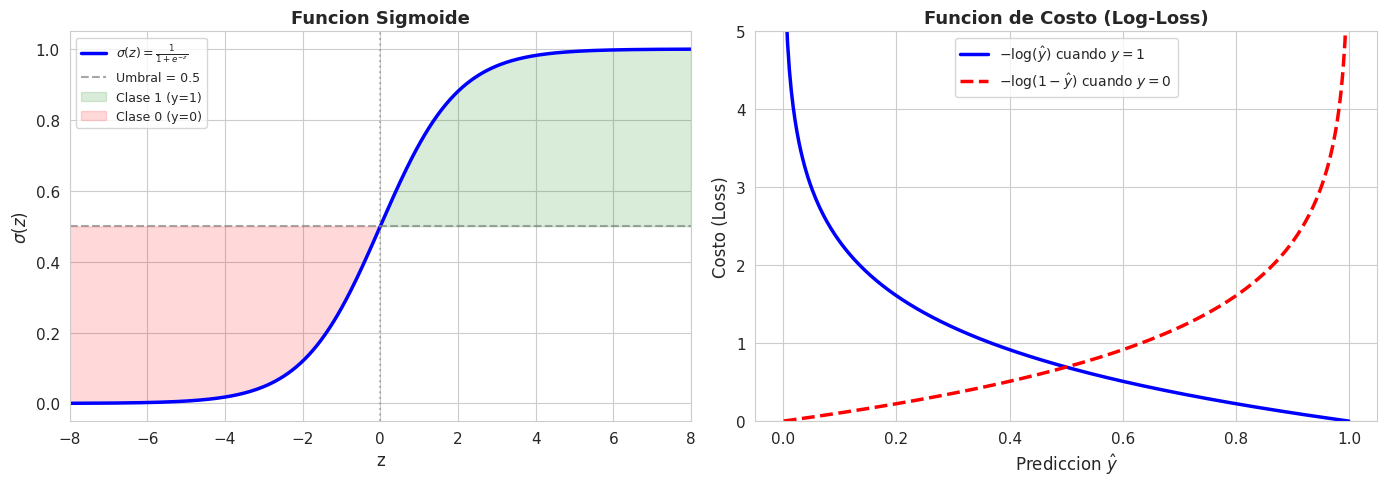

Interpretacion:
- Sigmoide: transforma z en probabilidad [0,1]. El umbral 0.5 separa las clases.
- Log-Loss: penaliza fuertemente las predicciones confiantes pero incorrectas.


In [ ]:
# Visualizacion de la funcion sigmoide y la funcion de costo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Funcion sigmoide ---
z = np.linspace(-8, 8, 300)
sigma = 1 / (1 + np.exp(-z))

axes[0].plot(z, sigma, 'b-', linewidth=2.5, label=r'$\sigma(z) = \frac{1}{1 + e^{-z}}$')
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Umbral = 0.5')
axes[0].axvline(x=0, color='gray', linestyle=':', alpha=0.5)
axes[0].fill_between(z, sigma, 0.5, where=(sigma >= 0.5), alpha=0.15, color='green', label='Clase 1 (y=1)')
axes[0].fill_between(z, sigma, 0.5, where=(sigma < 0.5), alpha=0.15, color='red', label='Clase 0 (y=0)')
axes[0].set_xlabel('z', fontsize=12)
axes[0].set_ylabel(r'$\sigma(z)$', fontsize=12)
axes[0].set_title('Funcion Sigmoide', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_ylim(-0.05, 1.05)
axes[0].set_xlim(-8, 8)

# --- Funcion de costo (log-loss) ---
y_hat = np.linspace(0.001, 0.999, 300)
loss_y1 = -np.log(y_hat)       # Costo cuando y=1
loss_y0 = -np.log(1 - y_hat)   # Costo cuando y=0

axes[1].plot(y_hat, loss_y1, 'b-', linewidth=2.5, label=r'$-\log(\hat{y})$ cuando $y=1$')
axes[1].plot(y_hat, loss_y0, 'r--', linewidth=2.5, label=r'$-\log(1-\hat{y})$ cuando $y=0$')
axes[1].set_xlabel(r'Prediccion $\hat{y}$', fontsize=12)
axes[1].set_ylabel('Costo (Loss)', fontsize=12)
axes[1].set_title('Funcion de Costo (Log-Loss)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].set_ylim(0, 5)

plt.tight_layout()
plt.show()

print('Interpretacion:')
print('- Sigmoide: transforma z en probabilidad [0,1]. El umbral 0.5 separa las clases.')
print('- Log-Loss: penaliza fuertemente las predicciones confiantes pero incorrectas.')

## Carga y Exploración del Dataset

In [ ]:
# Carga del dataset Wisconsin Breast Cancer
cancer = load_breast_cancer()
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target  # 0 = maligno, 1 = benigno
df['diagnostico'] = df['target'].map({0: 'Maligno', 1: 'Benigno'})

print('=== Informacion del Dataset ===')
print(f'Muestras: {df.shape[0]}')
print(f'Caracteristicas: {df.shape[1] - 2}')
print(f'Clases: {dict(zip(cancer.target_names, np.bincount(cancer.target)))}')
print(f'Valores faltantes: {df.isnull().sum().sum()}')
print()
print('=== Primeras 5 filas ===')
df.head()

=== Informacion del Dataset ===
Muestras: 569
Caracteristicas: 30
Clases: {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}
Valores faltantes: 0

=== Primeras 5 filas ===


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnostico
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Maligno
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Maligno
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Maligno
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Maligno
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Maligno


In [ ]:
# Estadisticas descriptivas
print('=== Estadisticas Descriptivas (primeras 10 caracteristicas) ===')
df[cancer.feature_names[:10]].describe().round(3)

=== Estadisticas Descriptivas (primeras 10 caracteristicas) ===


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension
count,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000
mean,14.127,19.290,91.969,654.889,0.096,0.104,0.089,0.049,0.181,0.063
std,3.524,4.301,24.299,351.914,0.014,0.053,0.080,0.039,0.027,0.007
min,6.981,9.710,43.790,143.500,0.053,0.019,0.000,0.000,0.106,0.050
25%,11.700,16.170,75.170,420.300,0.086,0.065,0.030,0.020,0.162,0.058
50%,13.370,18.840,86.240,551.100,0.096,0.093,0.062,0.034,0.179,0.062
75%,15.780,21.800,104.100,782.700,0.105,0.130,0.131,0.074,0.196,0.066
max,28.110,39.280,188.500,2501.000,0.163,0.345,0.427,0.201,0.304,0.097


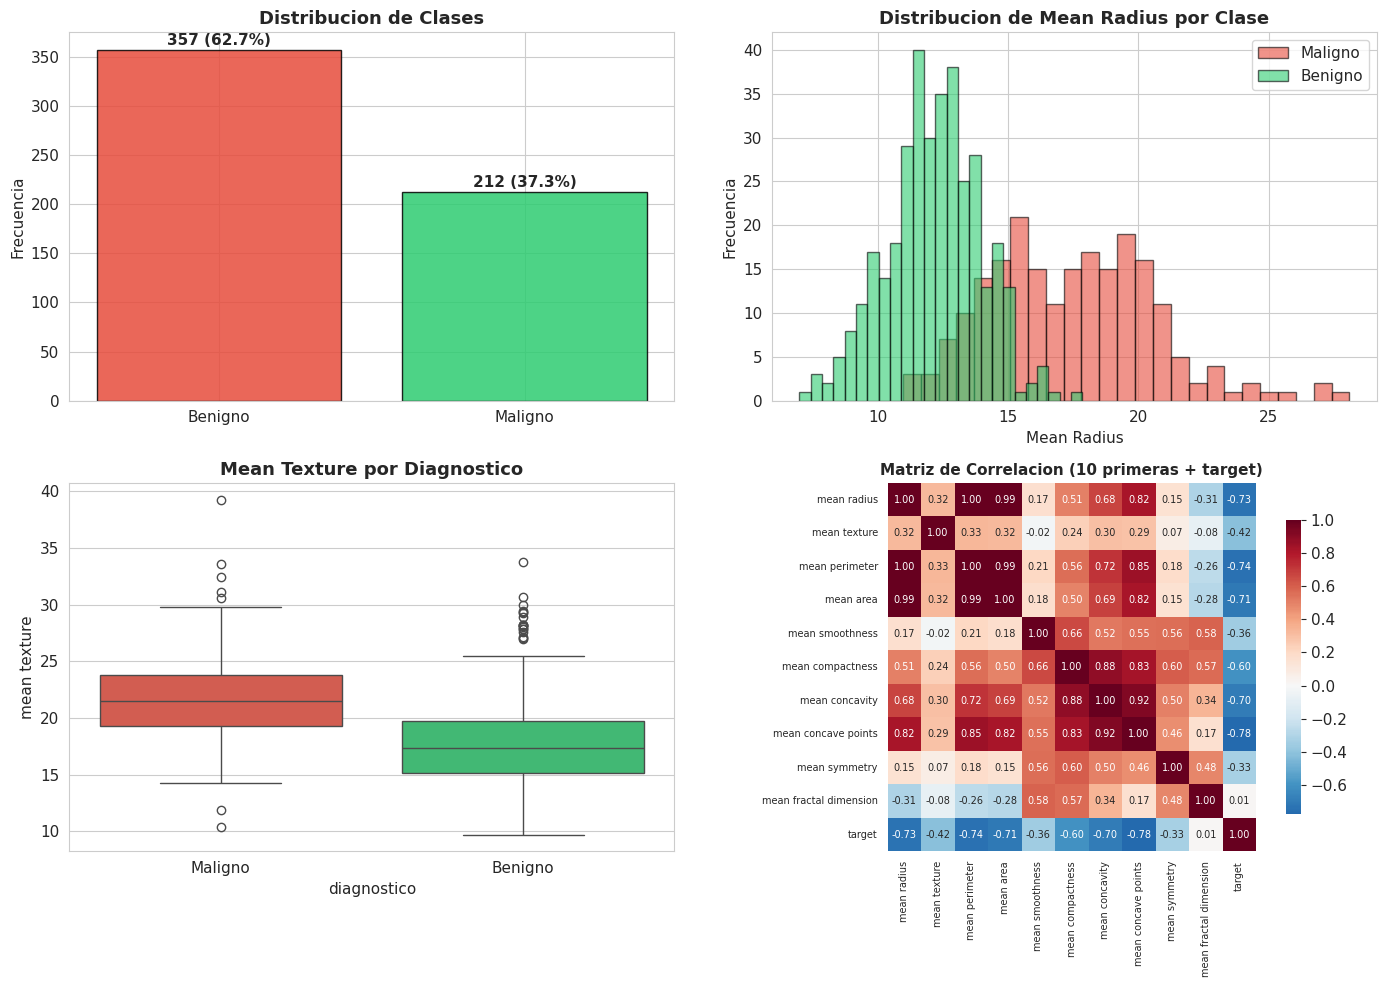

In [ ]:
# Visualizacion exploratoria
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribucion de clases
colors = ['#e74c3c', '#2ecc71']
counts = df['diagnostico'].value_counts()
axes[0, 0].bar(counts.index, counts.values, color=colors, edgecolor='black', alpha=0.85)
for i, (label, val) in enumerate(zip(counts.index, counts.values)):
    axes[0, 0].text(i, val + 5, f'{val} ({val/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0, 0].set_title('Distribucion de Clases', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Frecuencia')

# Distribucion de mean radius por clase
for diag, color in zip(['Maligno', 'Benigno'], colors):
    subset = df[df['diagnostico'] == diag]['mean radius']
    axes[0, 1].hist(subset, bins=25, alpha=0.6, color=color, label=diag, edgecolor='black')
axes[0, 1].set_title('Distribucion de Mean Radius por Clase', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Mean Radius')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].legend()

# Boxplot de mean texture por clase
sns.boxplot(data=df, x='diagnostico', y='mean texture', palette=colors, ax=axes[1, 0])
axes[1, 0].set_title('Mean Texture por Diagnostico', fontsize=13, fontweight='bold')

# Correlacion de las 10 principales caracteristicas
top_features = cancer.feature_names[:10]
corr_matrix = df[list(top_features) + ['target']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=axes[1, 1], cbar_kws={'shrink': 0.8},
            annot_kws={'size': 7})
axes[1, 1].set_title('Matriz de Correlacion (10 primeras + target)', fontsize=11, fontweight='bold')
axes[1, 1].tick_params(axis='both', labelsize=7)

plt.tight_layout()
plt.show()

## Preprocesamiento

In [ ]:
# Division train/test 80/20 estratificada + escalamiento
X = cancer.data
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('=== Division del Dataset ===')
print(f'Entrenamiento: {X_train.shape[0]} muestras ({X_train.shape[0]/len(y)*100:.0f}%)')
print(f'Prueba: {X_test.shape[0]} muestras ({X_test.shape[0]/len(y)*100:.0f}%)')
print(f'Clases en entrenamiento - Maligno: {(y_train==0).sum()}, Benigno: {(y_train==1).sum()}')
print(f'Clases en prueba - Maligno: {(y_test==0).sum()}, Benigno: {(y_test==1).sum()}')

# Escalamiento con StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'\nMedia de X_train escalado: {X_train_scaled.mean():.6f} (esperado ~0)')
print(f'Desv. est. de X_train escalado: {X_train_scaled.std():.6f} (esperado ~1)')

=== Division del Dataset ===
Entrenamiento: 455 muestras (80%)
Prueba: 114 muestras (20%)
Clases en entrenamiento - Maligno: 170, Benigno: 285
Clases en prueba - Maligno: 42, Benigno: 72

Media de X_train escalado: -0.000000 (esperado ~0)
Desv. est. de X_train escalado: 1.000000 (esperado ~1)


## Modelo Base de Regresión Logística

=== Metricas del Modelo Base ===
Exactitud (Accuracy):  0.9825
Precision:             0.9861
Exhaustividad (Recall):0.9861
F1-Score:              0.9861

=== Reporte de Clasificacion ===
              precision    recall  f1-score   support

     Maligno       0.98      0.98      0.98        42
     Benigno       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



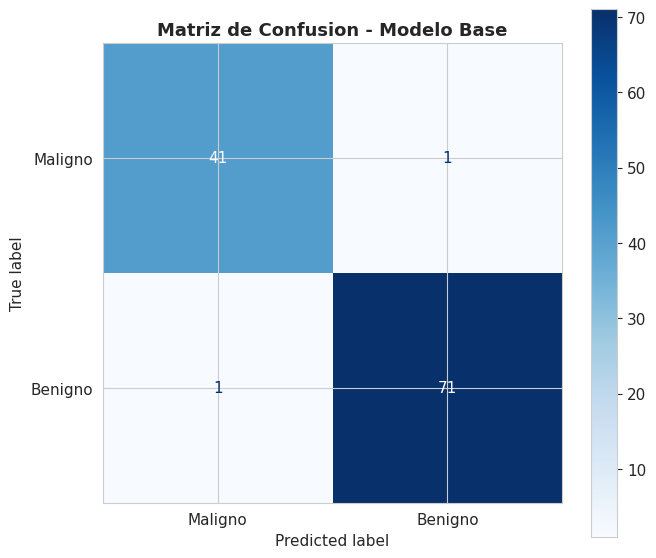


Verdaderos Negativos (Maligno correcto): 41
Falsos Positivos: 1
Falsos Negativos: 1
Verdaderos Positivos (Benigno correcto): 71
Especificidad: 0.9762


In [ ]:
# Entrenamiento del modelo base (regularizacion L2 por defecto)
modelo_base = LogisticRegression(max_iter=10000, random_state=42)
modelo_base.fit(X_train_scaled, y_train)

# Predicciones
y_pred = modelo_base.predict(X_test_scaled)
y_prob = modelo_base.predict_proba(X_test_scaled)[:, 1]

# Metricas
print('=== Metricas del Modelo Base ===')
print(f'Exactitud (Accuracy):  {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision:             {precision_score(y_test, y_pred):.4f}')
print(f'Exhaustividad (Recall):{recall_score(y_test, y_pred):.4f}')
print(f'F1-Score:              {f1_score(y_test, y_pred):.4f}')
print()
print('=== Reporte de Clasificacion ===')
print(classification_report(y_test, y_pred, target_names=['Maligno', 'Benigno']))

# Matriz de confusion
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Maligno', 'Benigno'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
ax.set_title('Matriz de Confusion - Modelo Base', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Interpretacion de la matriz
tn, fp, fn, tp = cm.ravel()
print(f'\nVerdaderos Negativos (Maligno correcto): {tn}')
print(f'Falsos Positivos: {fp}')
print(f'Falsos Negativos: {fn}')
print(f'Verdaderos Positivos (Benigno correcto): {tp}')
print(f'Especificidad: {tn / (tn + fp):.4f}')

##  Análisis de Regularización: L1 vs L2

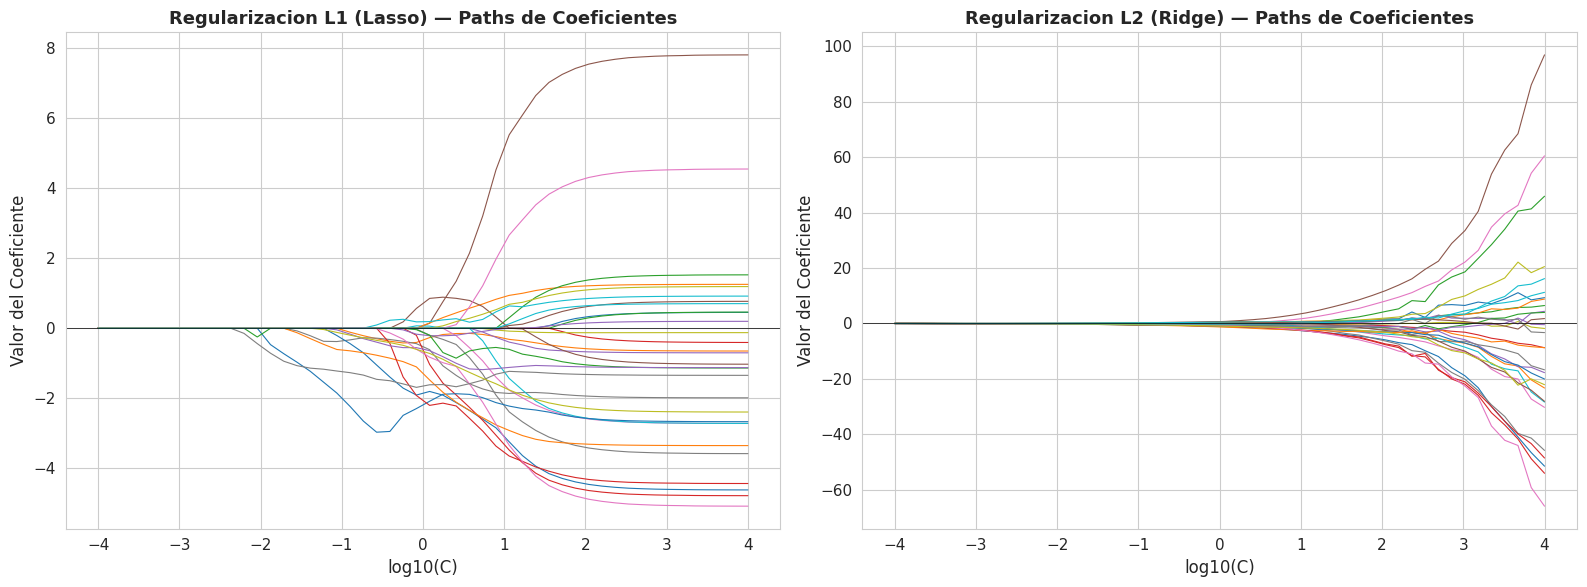

Con C=0.1 y L1: 22 de 30 coeficientes son exactamente 0 (seleccion de caracteristicas).
Exactitud L1 (C=0.1): 0.9737


In [ ]:
# Analisis del efecto de la regularizacion sobre los coeficientes
C_values = np.logspace(-4, 4, 50)

coefs_l1 = []
coefs_l2 = []

for C in C_values:
    # L1 (Lasso)
    lr_l1 = LogisticRegression(penalty='l1', C=C, solver='saga', max_iter=10000, random_state=42)
    lr_l1.fit(X_train_scaled, y_train)
    coefs_l1.append(lr_l1.coef_[0].copy())

    # L2 (Ridge)
    lr_l2 = LogisticRegression(penalty='l2', C=C, solver='lbfgs', max_iter=10000, random_state=42)
    lr_l2.fit(X_train_scaled, y_train)
    coefs_l2.append(lr_l2.coef_[0].copy())

coefs_l1 = np.array(coefs_l1)
coefs_l2 = np.array(coefs_l2)

# Visualizacion de paths de coeficientes
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i in range(coefs_l1.shape[1]):
    axes[0].plot(np.log10(C_values), coefs_l1[:, i], linewidth=0.8)
axes[0].set_xlabel('log10(C)', fontsize=12)
axes[0].set_ylabel('Valor del Coeficiente', fontsize=12)
axes[0].set_title('Regularizacion L1 (Lasso) — Paths de Coeficientes', fontsize=13, fontweight='bold')
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

for i in range(coefs_l2.shape[1]):
    axes[1].plot(np.log10(C_values), coefs_l2[:, i], linewidth=0.8)
axes[1].set_xlabel('log10(C)', fontsize=12)
axes[1].set_ylabel('Valor del Coeficiente', fontsize=12)
axes[1].set_title('Regularizacion L2 (Ridge) — Paths de Coeficientes', fontsize=13, fontweight='bold')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

# Conteo de coeficientes nulos en L1
best_l1 = LogisticRegression(penalty='l1', C=0.1, solver='saga', max_iter=10000, random_state=42)
best_l1.fit(X_train_scaled, y_train)
n_zeros = (best_l1.coef_[0] == 0).sum()
print(f'Con C=0.1 y L1: {n_zeros} de 30 coeficientes son exactamente 0 (seleccion de caracteristicas).')
print(f'Exactitud L1 (C=0.1): {best_l1.score(X_test_scaled, y_test):.4f}')

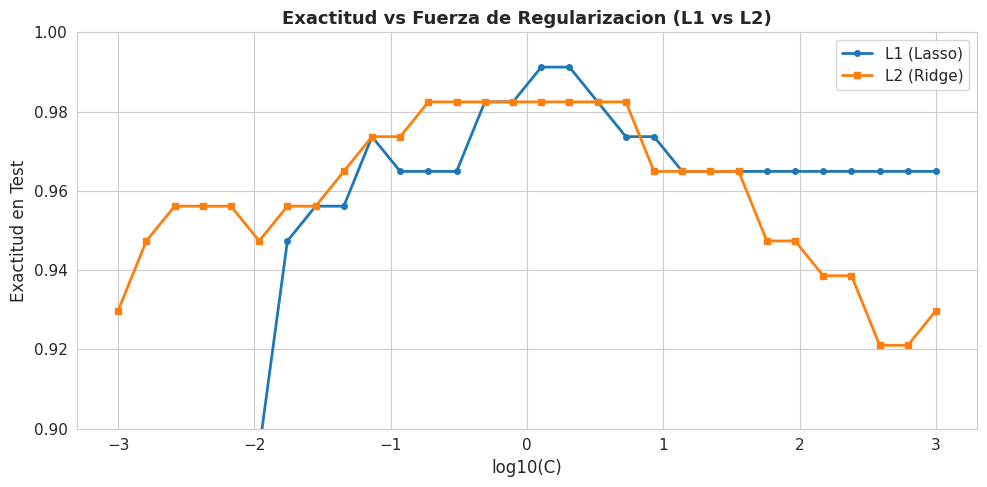

Mejor exactitud L1: 0.9912 con C=1.2690
Mejor exactitud L2: 0.9825 con C=0.1887


In [ ]:
# Comparacion de exactitud L1 vs L2 para diferentes valores de C
C_range = np.logspace(-3, 3, 30)
scores_l1 = []
scores_l2 = []

for C in C_range:
    lr_l1 = LogisticRegression(penalty='l1', C=C, solver='saga', max_iter=10000, random_state=42)
    lr_l1.fit(X_train_scaled, y_train)
    scores_l1.append(lr_l1.score(X_test_scaled, y_test))

    lr_l2 = LogisticRegression(penalty='l2', C=C, solver='lbfgs', max_iter=10000, random_state=42)
    lr_l2.fit(X_train_scaled, y_train)
    scores_l2.append(lr_l2.score(X_test_scaled, y_test))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(np.log10(C_range), scores_l1, 'o-', label='L1 (Lasso)', linewidth=2, markersize=4)
ax.plot(np.log10(C_range), scores_l2, 's-', label='L2 (Ridge)', linewidth=2, markersize=4)
ax.set_xlabel('log10(C)', fontsize=12)
ax.set_ylabel('Exactitud en Test', fontsize=12)
ax.set_title('Exactitud vs Fuerza de Regularizacion (L1 vs L2)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0.90, 1.0)
plt.tight_layout()
plt.show()

print(f'Mejor exactitud L1: {max(scores_l1):.4f} con C={C_range[np.argmax(scores_l1)]:.4f}')
print(f'Mejor exactitud L2: {max(scores_l2):.4f} con C={C_range[np.argmax(scores_l2)]:.4f}')

## Validación Cruzada Estratificada

=== Validacion Cruzada 10-Fold Estratificada ===
Exactitud:     0.9772 (+/- 0.0176)
F1-Score:      0.9821 (+/- 0.0137)
Precision:     0.9760 (+/- 0.0245)
Recall:        0.9888 (+/- 0.0185)

Scores por fold (Exactitud):
  Fold  1: 0.9825
  Fold  2: 0.9825
  Fold  3: 0.9474
  Fold  4: 0.9649
  Fold  5: 0.9825
  Fold  6: 0.9474
  Fold  7: 1.0000
  Fold  8: 0.9825
  Fold  9: 0.9825
  Fold 10: 1.0000


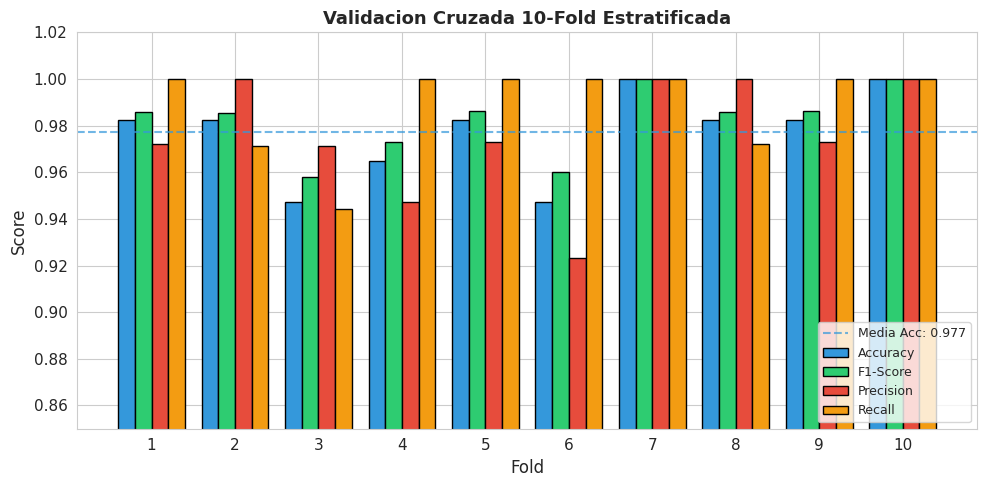

In [ ]:
# Validacion cruzada 10-fold estratificada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

modelo_cv = LogisticRegression(max_iter=10000, random_state=42)

# Metricas por fold
scores_accuracy = cross_val_score(modelo_cv, scaler.fit_transform(X), y, cv=cv, scoring='accuracy')
scores_f1 = cross_val_score(modelo_cv, scaler.fit_transform(X), y, cv=cv, scoring='f1')
scores_precision = cross_val_score(modelo_cv, scaler.fit_transform(X), y, cv=cv, scoring='precision')
scores_recall = cross_val_score(modelo_cv, scaler.fit_transform(X), y, cv=cv, scoring='recall')

print('=== Validacion Cruzada 10-Fold Estratificada ===')
print(f'Exactitud:     {scores_accuracy.mean():.4f} (+/- {scores_accuracy.std():.4f})')
print(f'F1-Score:      {scores_f1.mean():.4f} (+/- {scores_f1.std():.4f})')
print(f'Precision:     {scores_precision.mean():.4f} (+/- {scores_precision.std():.4f})')
print(f'Recall:        {scores_recall.mean():.4f} (+/- {scores_recall.std():.4f})')
print()
print('Scores por fold (Exactitud):')
for i, score in enumerate(scores_accuracy, 1):
    print(f'  Fold {i:2d}: {score:.4f}')

# Visualizacion
fig, ax = plt.subplots(figsize=(10, 5))
folds = range(1, 11)
width = 0.2

ax.bar([f - 1.5*width for f in folds], scores_accuracy, width, label='Accuracy', color='#3498db', edgecolor='black')
ax.bar([f - 0.5*width for f in folds], scores_f1, width, label='F1-Score', color='#2ecc71', edgecolor='black')
ax.bar([f + 0.5*width for f in folds], scores_precision, width, label='Precision', color='#e74c3c', edgecolor='black')
ax.bar([f + 1.5*width for f in folds], scores_recall, width, label='Recall', color='#f39c12', edgecolor='black')

ax.axhline(y=scores_accuracy.mean(), color='#3498db', linestyle='--', alpha=0.7, label=f'Media Acc: {scores_accuracy.mean():.3f}')
ax.set_xlabel('Fold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Validacion Cruzada 10-Fold Estratificada', fontsize=13, fontweight='bold')
ax.set_xticks(folds)
ax.set_ylim(0.85, 1.02)
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

##  Curva ROC y AUC

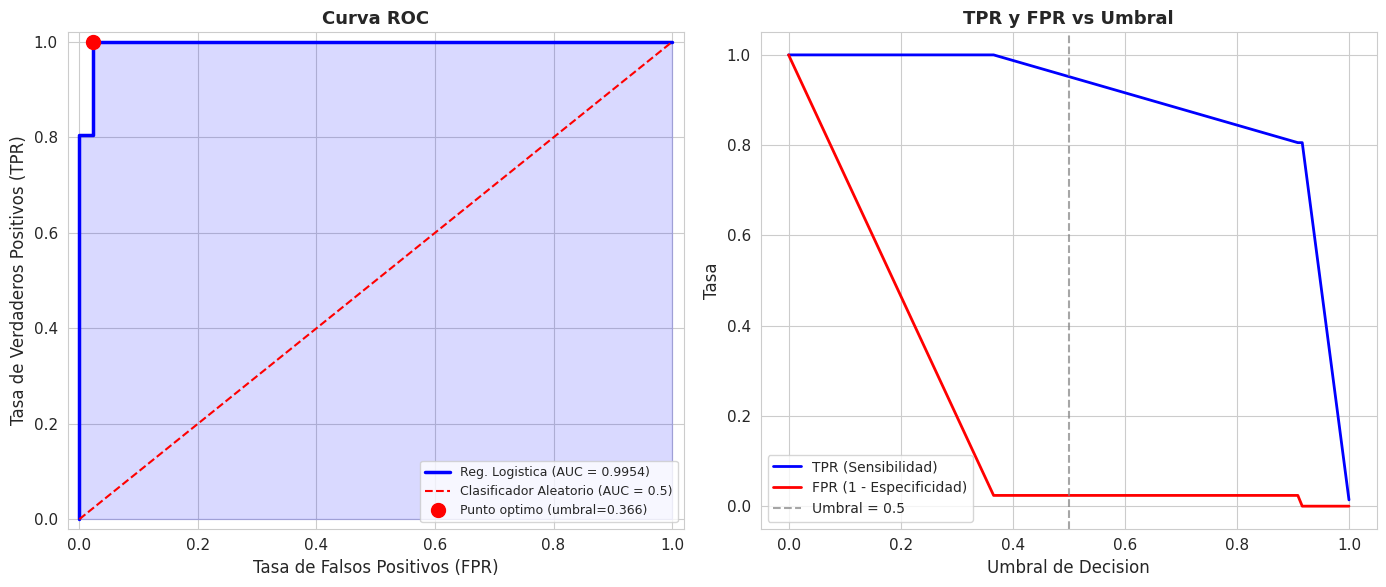

AUC-ROC: 0.9954
Umbral optimo (Youden): 0.3659
En el punto optimo — TPR: 1.0000, FPR: 0.0238


In [ ]:
# Curva ROC
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Curva ROC
axes[0].plot(fpr, tpr, 'b-', linewidth=2.5, label=f'Reg. Logistica (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Clasificador Aleatorio (AUC = 0.5)')
axes[0].fill_between(fpr, tpr, alpha=0.15, color='blue')
axes[0].set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
axes[0].set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
axes[0].set_title('Curva ROC', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10, loc='lower right')
axes[0].set_xlim([-0.02, 1.02])
axes[0].set_ylim([-0.02, 1.02])

# Punto optimo (Youden's J)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
axes[0].plot(fpr[best_idx], tpr[best_idx], 'ro', markersize=10,
             label=f'Punto optimo (umbral={thresholds_roc[best_idx]:.3f})')
axes[0].legend(fontsize=9, loc='lower right')

# TPR y FPR vs Umbral
axes[1].plot(thresholds_roc, tpr[:-1] if len(tpr) > len(thresholds_roc) else tpr,
             'b-', linewidth=2, label='TPR (Sensibilidad)')
axes[1].plot(thresholds_roc, fpr[:-1] if len(fpr) > len(thresholds_roc) else fpr,
             'r-', linewidth=2, label='FPR (1 - Especificidad)')
axes[1].axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label='Umbral = 0.5')
axes[1].set_xlabel('Umbral de Decision', fontsize=12)
axes[1].set_ylabel('Tasa', fontsize=12)
axes[1].set_title('TPR y FPR vs Umbral', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f'AUC-ROC: {roc_auc:.4f}')
print(f'Umbral optimo (Youden): {thresholds_roc[best_idx]:.4f}')
print(f'En el punto optimo — TPR: {tpr[best_idx]:.4f}, FPR: {fpr[best_idx]:.4f}')

##  Curva Precision-Recall y Análisis de Umbral

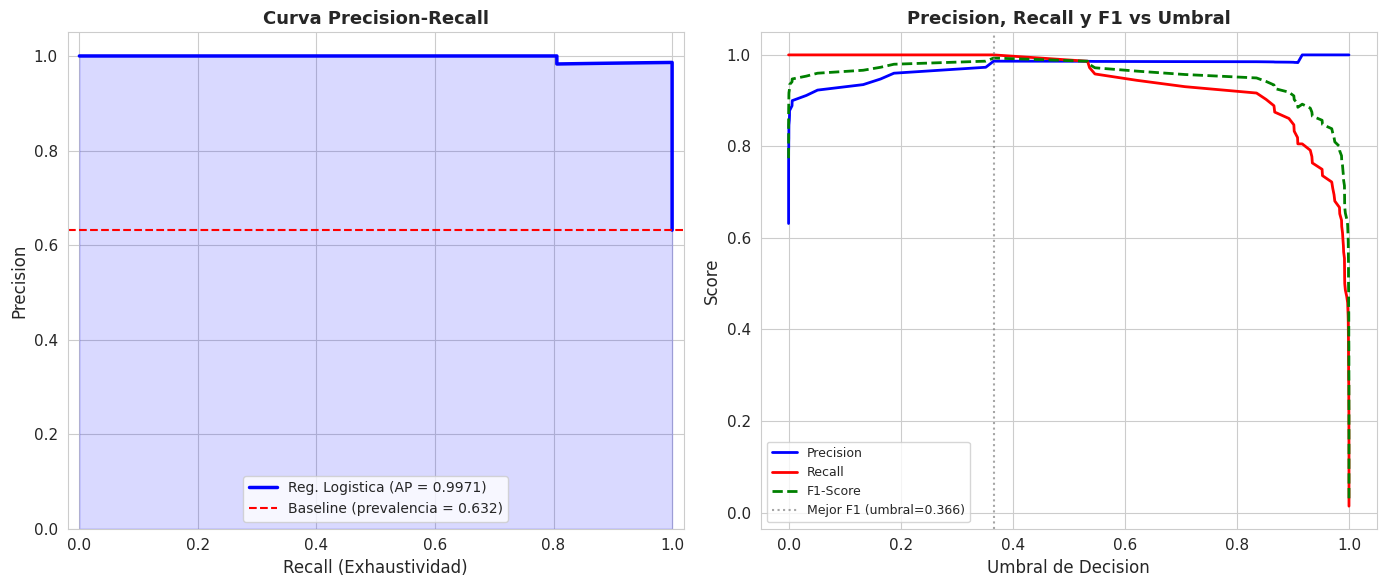

Average Precision (AP): 0.9971
Mejor F1-Score: 0.9931 con umbral 0.3659


In [ ]:
# Curva Precision-Recall
precision_curve, recall_curve, thresholds_pr = precision_recall_curve(y_test, y_prob)
ap_score = average_precision_score(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Curva PR
axes[0].plot(recall_curve, precision_curve, 'b-', linewidth=2.5,
             label=f'Reg. Logistica (AP = {ap_score:.4f})')
axes[0].fill_between(recall_curve, precision_curve, alpha=0.15, color='blue')
baseline = y_test.sum() / len(y_test)
axes[0].axhline(y=baseline, color='r', linestyle='--', linewidth=1.5,
                label=f'Baseline (prevalencia = {baseline:.3f})')
axes[0].set_xlabel('Recall (Exhaustividad)', fontsize=12)
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].set_title('Curva Precision-Recall', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].set_xlim([-0.02, 1.02])
axes[0].set_ylim([0.0, 1.05])

# Precision y Recall vs Umbral
axes[1].plot(thresholds_pr, precision_curve[:-1], 'b-', linewidth=2, label='Precision')
axes[1].plot(thresholds_pr, recall_curve[:-1], 'r-', linewidth=2, label='Recall')

# F1 vs umbral
f1_scores = 2 * (precision_curve[:-1] * recall_curve[:-1]) / (precision_curve[:-1] + recall_curve[:-1] + 1e-10)
axes[1].plot(thresholds_pr, f1_scores, 'g--', linewidth=2, label='F1-Score')

best_f1_idx = np.argmax(f1_scores)
axes[1].axvline(x=thresholds_pr[best_f1_idx], color='gray', linestyle=':', alpha=0.7,
                label=f'Mejor F1 (umbral={thresholds_pr[best_f1_idx]:.3f})')
axes[1].set_xlabel('Umbral de Decision', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Precision, Recall y F1 vs Umbral', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'Average Precision (AP): {ap_score:.4f}')
print(f'Mejor F1-Score: {f1_scores[best_f1_idx]:.4f} con umbral {thresholds_pr[best_f1_idx]:.4f}')

## Importancia de Características

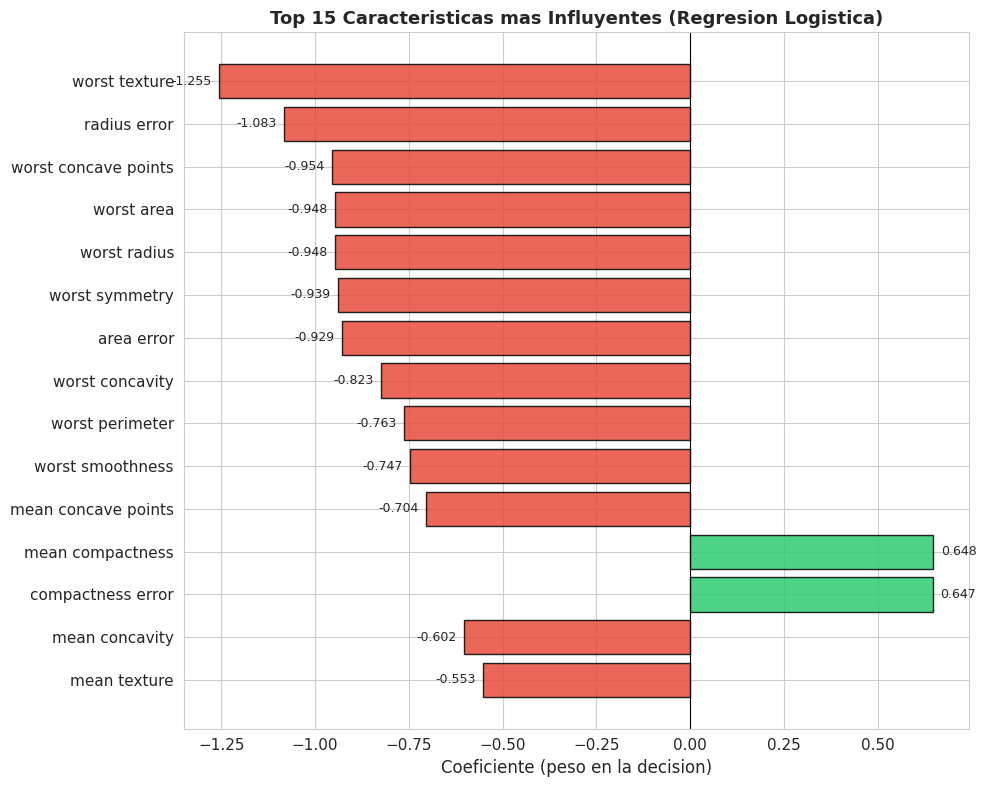

Interpretacion:
- Coeficientes positivos (verde): aumentan la probabilidad de diagnostico benigno.
- Coeficientes negativos (rojo): aumentan la probabilidad de diagnostico maligno.

Caracteristica mas influyente: worst texture (coef = -1.2551)


In [ ]:
# Importancia de caracteristicas basada en coeficientes del modelo
coeficientes = modelo_base.coef_[0]
feature_importance = pd.DataFrame({
    'Caracteristica': cancer.feature_names,
    'Coeficiente': coeficientes,
    'Abs_Coef': np.abs(coeficientes)
}).sort_values('Abs_Coef', ascending=True)

# Visualizacion Top 15
top15 = feature_importance.tail(15)

fig, ax = plt.subplots(figsize=(10, 8))
colors_bar = ['#e74c3c' if c < 0 else '#2ecc71' for c in top15['Coeficiente']]
ax.barh(top15['Caracteristica'], top15['Coeficiente'], color=colors_bar, edgecolor='black', alpha=0.85)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente (peso en la decision)', fontsize=12)
ax.set_title('Top 15 Caracteristicas mas Influyentes (Regresion Logistica)', fontsize=13, fontweight='bold')

# Anotaciones
for i, (_, row) in enumerate(top15.iterrows()):
    ax.text(row['Coeficiente'] + (0.02 if row['Coeficiente'] >= 0 else -0.02),
            i, f'{row["Coeficiente"]:.3f}',
            va='center', ha='left' if row['Coeficiente'] >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

print('Interpretacion:')
print('- Coeficientes positivos (verde): aumentan la probabilidad de diagnostico benigno.')
print('- Coeficientes negativos (rojo): aumentan la probabilidad de diagnostico maligno.')
print(f'\nCaracteristica mas influyente: {feature_importance.iloc[-1]["Caracteristica"]} '
      f'(coef = {feature_importance.iloc[-1]["Coeficiente"]:.4f})')

##  Frontera de Decisión (PCA 2D)

Varianza explicada por PC1: 0.4441 (44.4%)
Varianza explicada por PC2: 0.1894 (18.9%)
Varianza total explicada: 0.6336 (63.4%)
Exactitud con 2 componentes PCA: 0.9474


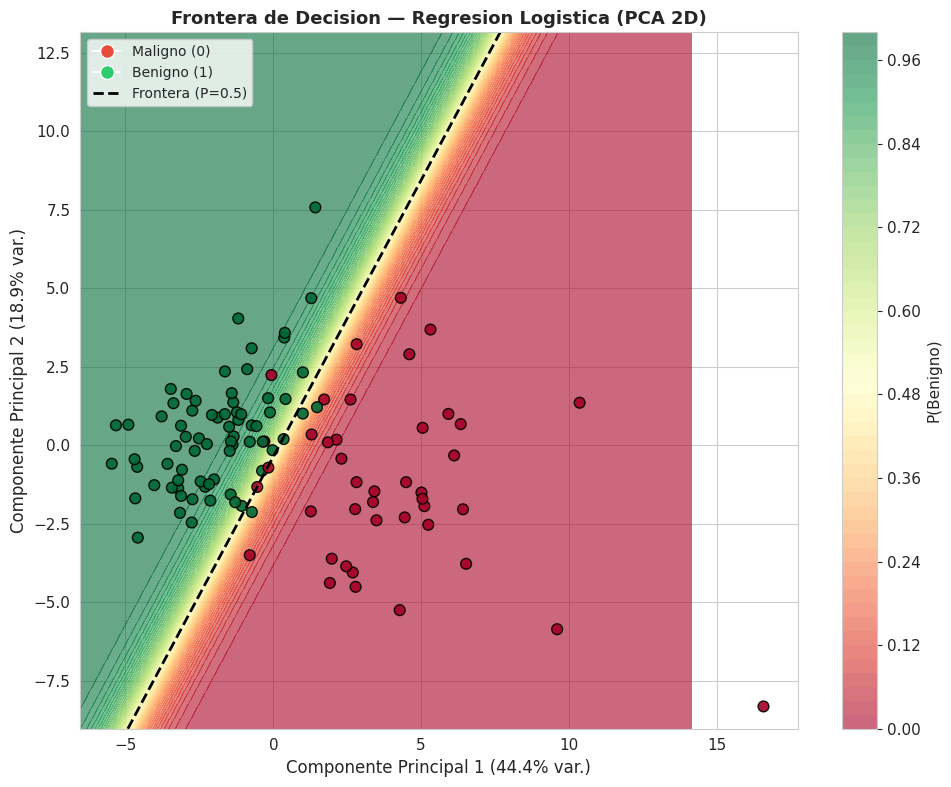

In [ ]:
# Reduccion a 2D con PCA para visualizar la frontera de decision
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f'Varianza explicada por PC1: {pca.explained_variance_ratio_[0]:.4f} ({pca.explained_variance_ratio_[0]*100:.1f}%)')
print(f'Varianza explicada por PC2: {pca.explained_variance_ratio_[1]:.4f} ({pca.explained_variance_ratio_[1]*100:.1f}%)')
print(f'Varianza total explicada: {pca.explained_variance_ratio_.sum():.4f} ({pca.explained_variance_ratio_.sum()*100:.1f}%)')

# Entrenar modelo en espacio PCA
modelo_pca = LogisticRegression(max_iter=10000, random_state=42)
modelo_pca.fit(X_train_pca, y_train)
acc_pca = modelo_pca.score(X_test_pca, y_test)
print(f'Exactitud con 2 componentes PCA: {acc_pca:.4f}')

# Frontera de decision
fig, ax = plt.subplots(figsize=(10, 8))

# Crear malla
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

Z = modelo_pca.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

# Contorno de probabilidad
contour = ax.contourf(xx, yy, Z, levels=50, cmap='RdYlGn', alpha=0.6)
plt.colorbar(contour, ax=ax, label='P(Benigno)')

# Frontera de decision (P=0.5)
ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2, linestyles='--')

# Puntos de datos
scatter = ax.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test,
                     cmap='RdYlGn', edgecolors='black', s=60, alpha=0.9)

ax.set_xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)', fontsize=12)
ax.set_ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)', fontsize=12)
ax.set_title('Frontera de Decision — Regresion Logistica (PCA 2D)', fontsize=13, fontweight='bold')

# Leyenda manual
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=10, label='Maligno (0)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ecc71', markersize=10, label='Benigno (1)'),
    Line2D([0], [0], color='black', linestyle='--', linewidth=2, label='Frontera (P=0.5)')
]
ax.legend(handles=legend_elements, fontsize=10, loc='upper left')

plt.tight_layout()
plt.show()

## Dashboard Integrado

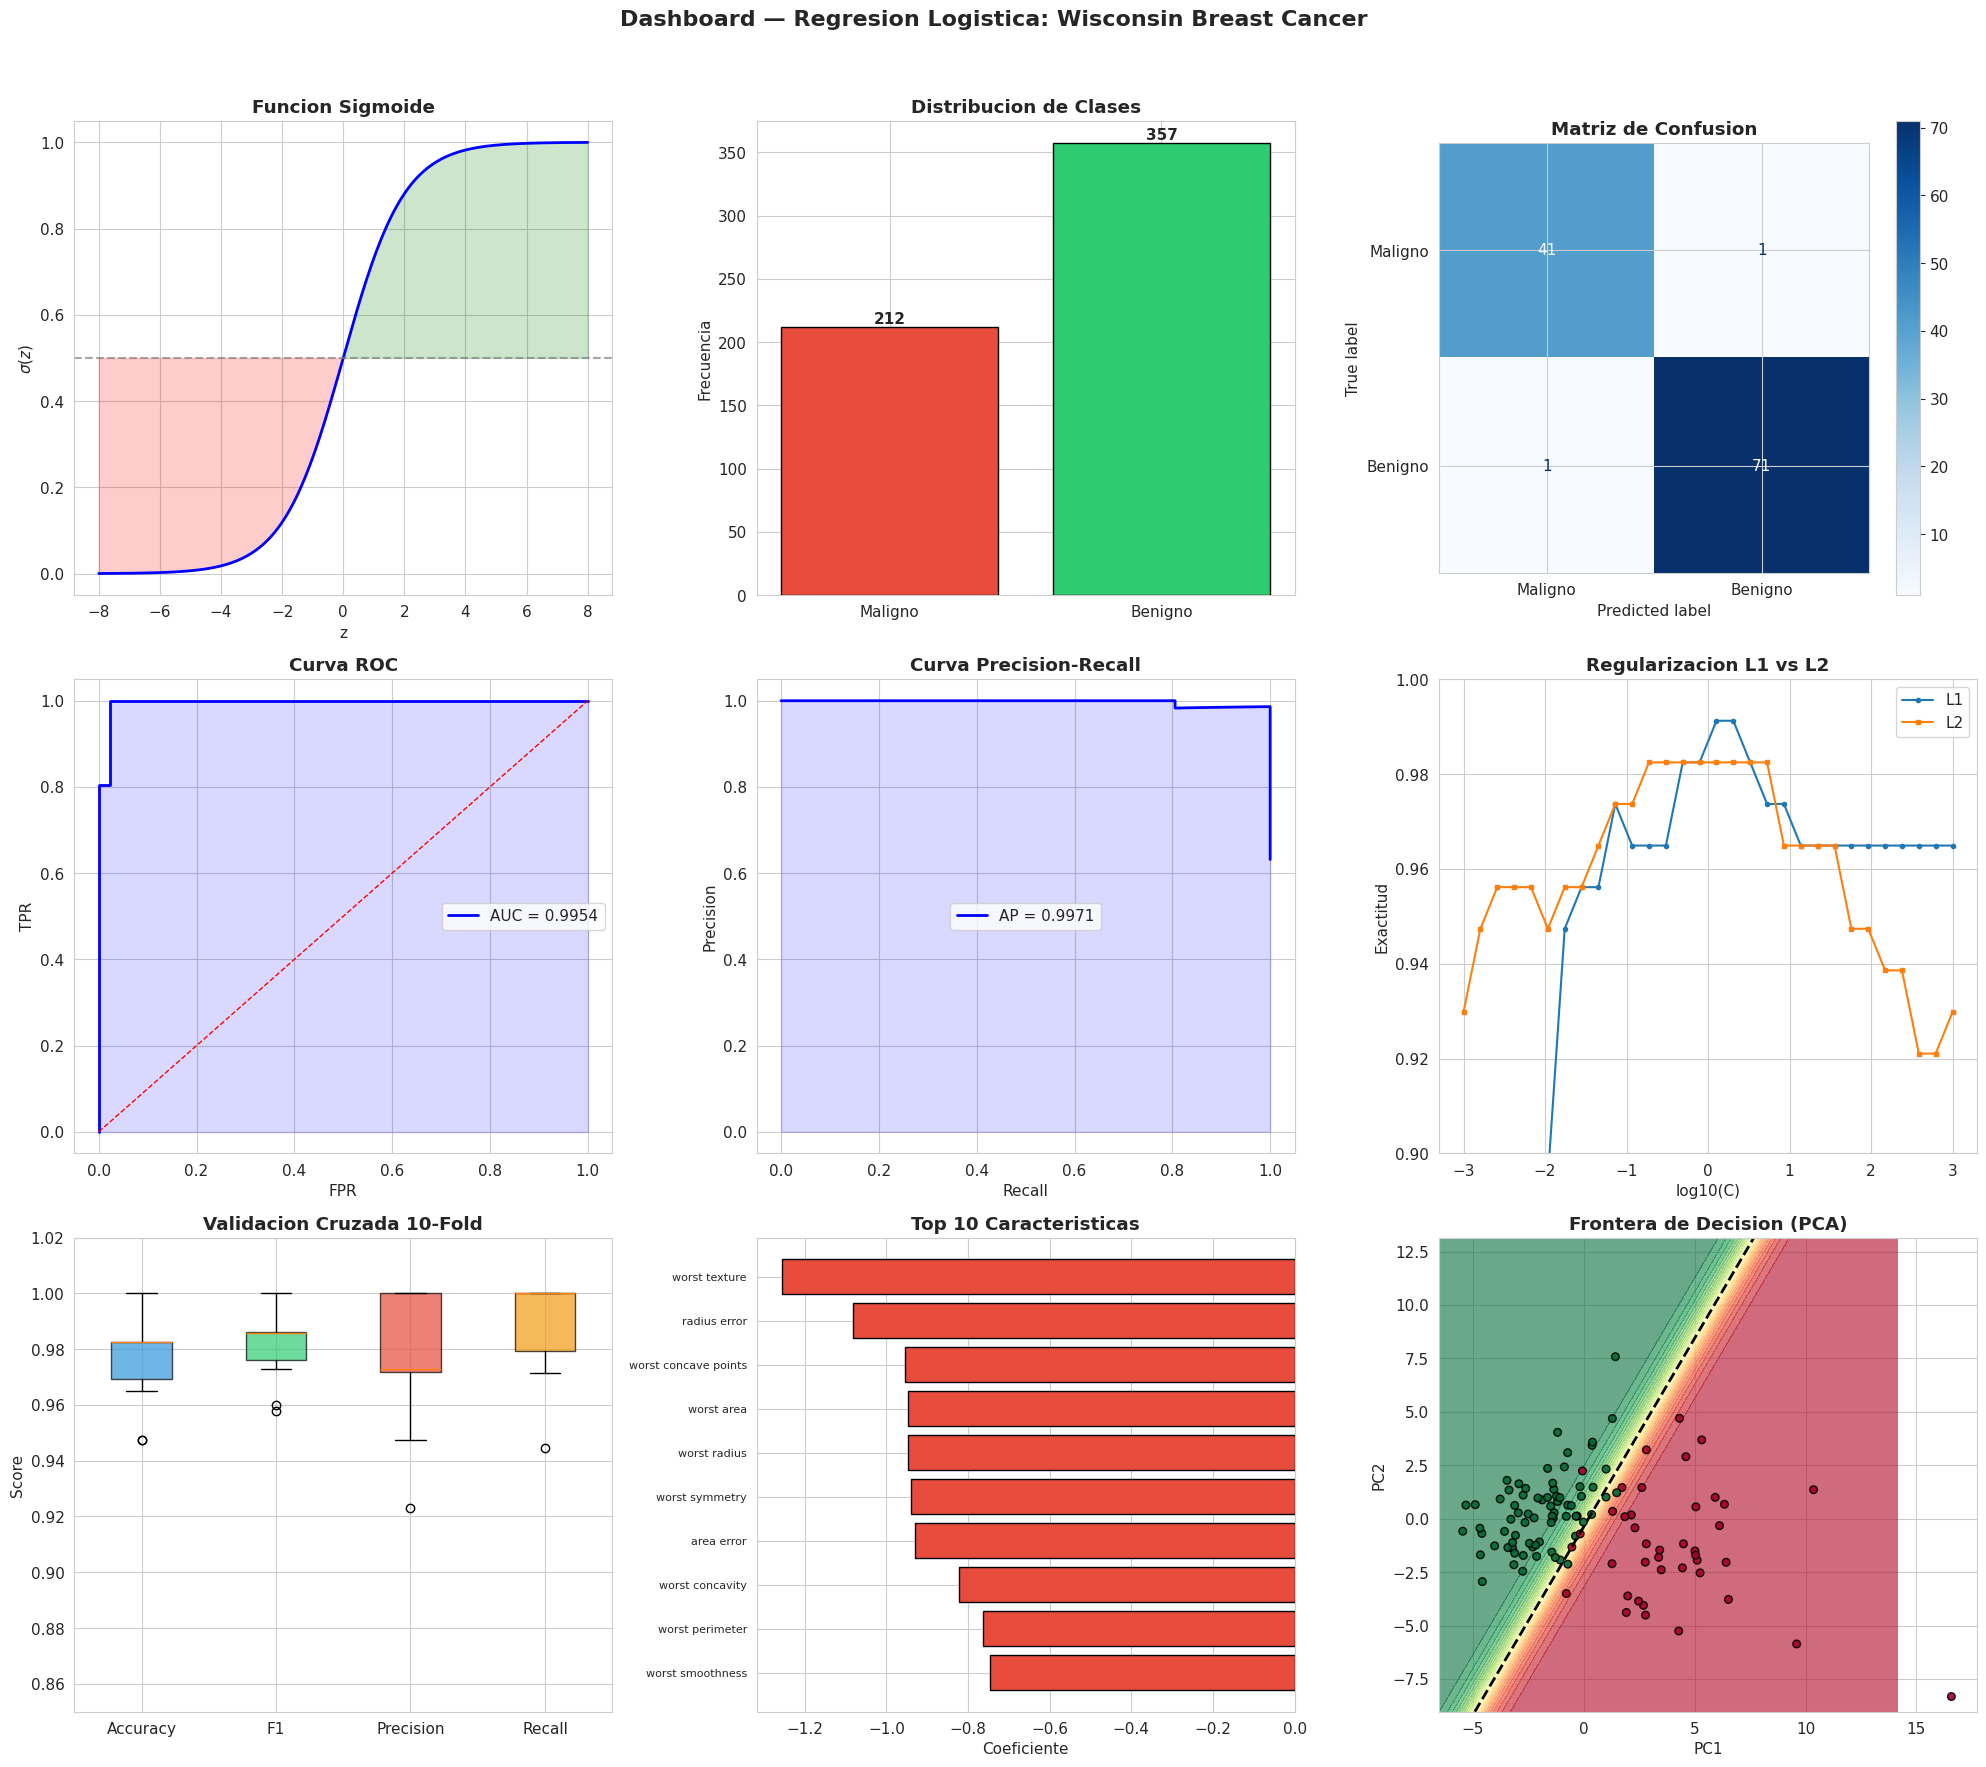

Dashboard generado con 9 paneles integrados.


In [ ]:
# Dashboard integrado con 9 paneles
fig, axes = plt.subplots(3, 3, figsize=(20, 18))
fig.suptitle('Dashboard — Regresion Logistica: Wisconsin Breast Cancer',
             fontsize=16, fontweight='bold', y=0.98)

# Panel 1: Funcion sigmoide
z_vals = np.linspace(-8, 8, 200)
sig_vals = 1 / (1 + np.exp(-z_vals))
axes[0, 0].plot(z_vals, sig_vals, 'b-', linewidth=2)
axes[0, 0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.7)
axes[0, 0].fill_between(z_vals, sig_vals, 0.5, where=(sig_vals >= 0.5), alpha=0.2, color='green')
axes[0, 0].fill_between(z_vals, sig_vals, 0.5, where=(sig_vals < 0.5), alpha=0.2, color='red')
axes[0, 0].set_title('Funcion Sigmoide', fontweight='bold')
axes[0, 0].set_xlabel('z')
axes[0, 0].set_ylabel(r'$\sigma(z)$')

# Panel 2: Distribucion de clases
class_counts = [np.sum(y == 0), np.sum(y == 1)]
bars = axes[0, 1].bar(['Maligno', 'Benigno'], class_counts, color=['#e74c3c', '#2ecc71'], edgecolor='black')
for bar, count in zip(bars, class_counts):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 3,
                    f'{count}', ha='center', fontweight='bold')
axes[0, 1].set_title('Distribucion de Clases', fontweight='bold')
axes[0, 1].set_ylabel('Frecuencia')

# Panel 3: Matriz de confusion
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Maligno', 'Benigno'])
cm_display.plot(cmap='Blues', ax=axes[0, 2], values_format='d')
axes[0, 2].set_title('Matriz de Confusion', fontweight='bold')

# Panel 4: Curva ROC
axes[1, 0].plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {roc_auc:.4f}')
axes[1, 0].plot([0, 1], [0, 1], 'r--', linewidth=1)
axes[1, 0].fill_between(fpr, tpr, alpha=0.15, color='blue')
axes[1, 0].set_title('Curva ROC', fontweight='bold')
axes[1, 0].set_xlabel('FPR')
axes[1, 0].set_ylabel('TPR')
axes[1, 0].legend()

# Panel 5: Curva Precision-Recall
axes[1, 1].plot(recall_curve, precision_curve, 'b-', linewidth=2, label=f'AP = {ap_score:.4f}')
axes[1, 1].fill_between(recall_curve, precision_curve, alpha=0.15, color='blue')
axes[1, 1].set_title('Curva Precision-Recall', fontweight='bold')
axes[1, 1].set_xlabel('Recall')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].legend()

# Panel 6: Regularizacion L1 vs L2 (exactitud)
axes[1, 2].plot(np.log10(C_range), scores_l1, 'o-', label='L1', markersize=3, linewidth=1.5)
axes[1, 2].plot(np.log10(C_range), scores_l2, 's-', label='L2', markersize=3, linewidth=1.5)
axes[1, 2].set_title('Regularizacion L1 vs L2', fontweight='bold')
axes[1, 2].set_xlabel('log10(C)')
axes[1, 2].set_ylabel('Exactitud')
axes[1, 2].set_ylim(0.90, 1.0)
axes[1, 2].legend()

# Panel 7: Validacion cruzada
bp = axes[2, 0].boxplot([scores_accuracy, scores_f1, scores_precision, scores_recall],
                        labels=['Accuracy', 'F1', 'Precision', 'Recall'],
                        patch_artist=True)
colors_box = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2, 0].set_title('Validacion Cruzada 10-Fold', fontweight='bold')
axes[2, 0].set_ylabel('Score')
axes[2, 0].set_ylim(0.85, 1.02)

# Panel 8: Importancia de caracteristicas (Top 10)
top10 = feature_importance.tail(10)
colors_h = ['#e74c3c' if c < 0 else '#2ecc71' for c in top10['Coeficiente']]
axes[2, 1].barh(top10['Caracteristica'], top10['Coeficiente'], color=colors_h, edgecolor='black')
axes[2, 1].axvline(x=0, color='black', linewidth=0.5)
axes[2, 1].set_title('Top 10 Caracteristicas', fontweight='bold')
axes[2, 1].set_xlabel('Coeficiente')
axes[2, 1].tick_params(axis='y', labelsize=8)

# Panel 9: Frontera de decision PCA
contour9 = axes[2, 2].contourf(xx, yy, Z, levels=30, cmap='RdYlGn', alpha=0.6)
axes[2, 2].contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2, linestyles='--')
axes[2, 2].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test,
                   cmap='RdYlGn', edgecolors='black', s=30, alpha=0.9)
axes[2, 2].set_title('Frontera de Decision (PCA)', fontweight='bold')
axes[2, 2].set_xlabel('PC1')
axes[2, 2].set_ylabel('PC2')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print('Dashboard generado con 9 paneles integrados.')

## Conclusiones

 la regresion logistica mas alla de una implementacion basica, abarcando tanto los fundamentos matematicos como las tecnicas avanzadas de evaluacion y regularizacion. Las principales conclusiones son:

1. **Identificacion de datasets aplicables.** La regresion logistica es idonea para problemas de clasificacion binaria con variable dependiente categorica y relacion lineal entre predictores y log-odds. El dataset Wisconsin Breast Cancer cumple estas condiciones y permite obtener resultados sobresalientes.

2. **Uso efectivo de librerias Python.** scikit-learn, NumPy, pandas, Matplotlib y seaborn conforman un ecosistema robusto que permite implementar, evaluar y visualizar modelos de regresion logistica de manera integral (Pedregosa et al., 2011).

3. **Fundamentos matematicos.** La comprension de la funcion sigmoide, la funcion de costo (binary cross-entropy) y el gradiente descendente resulta esencial para interpretar correctamente el comportamiento del modelo y ajustar sus hiperparametros.

4. **Regularizacion como herramienta clave.** El analisis comparativo de L1 y L2 demostro que la regularizacion controla el sobreajuste y que L1 realiza seleccion automatica de caracteristicas, reduciendo la dimensionalidad del problema.

5. **Evaluacion robusta.** La validacion cruzada 10-fold estratificada, las curvas ROC y Precision-Recall, y el analisis de umbral proporcionaron una evaluacion integral del modelo, superando las limitaciones de una sola metrica (Fawcett, 2006).

6. **Consideraciones eticas.** En aplicaciones de diagnostico medico, minimizar los falsos negativos es critico. Los modelos de machine learning deben utilizarse como apoyo a la decision clinica, no como reemplazo del juicio profesional.

## Referencias

Bagnato, J. I. (2017). Regresion Logistica con Python paso a paso. *Aprende Machine Learning*. https://www.aprendemachinelearning.com/regresion-logistica-con-python-paso-a-paso/

Fawcett, T. (2006). An introduction to ROC analysis. *Pattern Recognition Letters*, *27*(8), 861-874. https://doi.org/10.1016/j.patrec.2005.10.010

Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E., Taylor, J., Berg, S., Smith, N. J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M. H., Brett, M., Haldane, A., del Rio, J. F., Wiebe, M., Peterson, P., ... Oliphant, T. E. (2020). Array programming with NumPy. *Nature*, *585*(7825), 357-362. https://doi.org/10.1038/s41586-020-2649-2

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering*, *9*(3), 90-95. https://doi.org/10.1109/MCSE.2007.55

Lee, W. (2019). *Python machine learning* (pp. 151-174). John Wiley & Sons.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M. y Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, *12*, 2825-2830.

Theodoridis, S. (2015). *Machine learning: A Bayesian and optimization perspective* (pp. 53-102). Elsevier Academic Press.